<a href="https://colab.research.google.com/github/abidahnisaa/Project_Breast_Cancer_Poster_Presentation_UNS/blob/main/1.Filtering_DepMap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import re

In [3]:
df_raw = pd.read_csv("/content/drive/MyDrive/Breast Cancer Model/CRISPR_(DepMap_Public_26Q1+Score,_Chronos)_subsetted.csv")

df_raw.shape
df_raw.head(10)

/tmp/ipykernel_12727/657553033.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("/content/drive/MyDrive/Breast Cancer Model/CRISPR_(DepMap_Public_26Q1+Score,_Chronos)_subsetted.csv")


,depmap_id,cell_line_display_name,lineage_1,lineage_2,lineage_3,lineage_6,lineage_4,A1BG,AASS,ABCA10,...,ZNF432,ZNF516,ZNF518A,ZNF536,ZNF592,ZNF623,ZNF646,ZSCAN12,CCL4L2,CDK11B
0,ACH-001270,127399,Soft Tissue,Synovial Sarcoma,Synovial Sarcoma,NaN,NaN,-0.038756,-0.215523,0.044912,...,0.017046,NaN,NaN,0.014567,0.161617,0.019846,-0.264657,NaN,NaN,NaN
1,ACH-002680,170MGBA,CNS/Brain,Adult-Type Diffuse Glioma,"Glioblastoma, IDH-Wildtype",NaN,NaN,-0.007730,0.041877,0.066959,...,0.105222,NaN,NaN,-0.022810,0.004996,-0.052879,-0.051166,NaN,NaN,NaN
2,ACH-002400,21MT1,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,HER2+,NaN,0.099750,0.095358,0.224868,...,0.031457,NaN,NaN,-0.131265,0.080008,0.041570,-0.036201,NaN,NaN,NaN
3,ACH-002401,21MT2,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,HER2+,NaN,0.032844,0.006765,0.289841,...,0.021381,NaN,NaN,-0.185839,0.114350,0.047070,-0.188832,NaN,NaN,NaN
4,ACH-002399,21NT,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,HER2+,NaN,0.095898,0.224174,0.137069,...,0.017857,NaN,NaN,0.000366,0.198231,-0.119213,-0.073809,NaN,NaN,NaN
5,ACH-003587,531MII,Bone,Osteosarcoma,Osteosarcoma,NaN,NaN,0.024135,0.162219,0.167984,...,0.167283,-0.082624,-0.021154,-0.087186,0.056861,0.124111,-0.109908,-0.085061,NaN,NaN
6,ACH-000520,59M,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,NaN,NaN,-0.178656,0.155504,0.153620,...,0.147552,NaN,NaN,-0.046993,0.322377,-0.088644,-0.172281,NaN,NaN,NaN
7,ACH-000973,639V,Bladder/Urinary Tract,Urethral Cancer,Urethral Urothelial Carcinoma,NaN,NaN,0.005265,0.036870,-0.127377,...,0.066856,NaN,NaN,-0.076016,0.044148,0.036761,-0.116984,NaN,NaN,NaN
8,ACH-001795,94T778,Soft Tissue,Liposarcoma,Well-Differentiated Liposarcoma,NaN,NaN,-0.009085,-0.042723,0.175865,...,-0.008944,NaN,NaN,-0.045426,0.394939,-0.000253,-0.085085,NaN,NaN,NaN
9,ACH-001999,9505BIK,Pancreas,Pancreatic Adenocarcinoma,Pancreatic Adenocarcinoma,NaN,NaN,-0.058257,0.287813,-0.193437,...,-0.044346,NaN,NaN,0.024208,-0.042170,-0.240379,0.038229,NaN,NaN,NaN


In [4]:
df_renamed = df_raw.rename(columns={
    "depmap_id": "model_id",
    "cell_line_display_name": "cell_line_name",
    "lineage_1": "oncotree_lineage",
    "lineage_2": "oncotree_primary_disease",
    "lineage_3": "oncotree_subtype"
})

df_renamed.head(100)

,model_id,cell_line_name,oncotree_lineage,oncotree_primary_disease,oncotree_subtype,lineage_6,lineage_4,A1BG,AASS,ABCA10,...,ZNF432,ZNF516,ZNF518A,ZNF536,ZNF592,ZNF623,ZNF646,ZSCAN12,CCL4L2,CDK11B
0,ACH-001270,127399,Soft Tissue,Synovial Sarcoma,Synovial Sarcoma,NaN,NaN,-0.038756,-0.215523,0.044912,...,0.017046,NaN,NaN,0.014567,0.161617,0.019846,-0.264657,NaN,NaN,NaN
1,ACH-002680,170MGBA,CNS/Brain,Adult-Type Diffuse Glioma,"Glioblastoma, IDH-Wildtype",NaN,NaN,-0.007730,0.041877,0.066959,...,0.105222,NaN,NaN,-0.022810,0.004996,-0.052879,-0.051166,NaN,NaN,NaN
2,ACH-002400,21MT1,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,HER2+,NaN,0.099750,0.095358,0.224868,...,0.031457,NaN,NaN,-0.131265,0.080008,0.041570,-0.036201,NaN,NaN,NaN
3,ACH-002401,21MT2,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,HER2+,NaN,0.032844,0.006765,0.289841,...,0.021381,NaN,NaN,-0.185839,0.114350,0.047070,-0.188832,NaN,NaN,NaN
4,ACH-002399,21NT,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,HER2+,NaN,0.095898,0.224174,0.137069,...,0.017857,NaN,NaN,0.000366,0.198231,-0.119213,-0.073809,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,ACH-000633,FU97,Esophagus/Stomach,Esophagogastric Adenocarcinoma,Diffuse Type Stomach Adenocarcinoma,NaN,NaN,0.026470,0.103962,0.149722,...,0.017910,NaN,NaN,0.031225,-0.061094,0.063351,-0.210258,NaN,NaN,NaN
96,ACH-002239,H3118,Head and Neck,Salivary Carcinoma,Mucoepidermoid Carcinoma,NaN,NaN,-0.011085,0.189147,-0.124184,...,-0.262401,NaN,NaN,-0.164486,-0.512328,-0.056615,-0.051226,NaN,NaN,NaN
97,ACH-001508,H314,Head and Neck,Head and Neck Squamous Cell Carcinoma,Oral Cavity Squamous Cell Carcinoma,NaN,NaN,0.085641,0.008080,0.068033,...,0.378795,NaN,NaN,-0.289145,0.070011,-0.029980,-0.013957,NaN,NaN,NaN
98,ACH-001310,HA1E,Kidney,Non-Cancerous,Immortalized Embyonic Kidney Cells,NaN,NaN,-0.119890,0.024621,0.256396,...,0.175133,NaN,NaN,0.128781,0.269691,-0.346653,-0.081113,NaN,NaN,NaN


In [5]:
df_stripped = df_renamed.copy()

df_stripped.insert(
    2,
    "stripped_cell_line_name",
    df_stripped["cell_line_name"]
    .astype(str)
    .apply(lambda x: re.sub(r"[^A-Za-z0-9]", "", x).upper())
)

df_stripped.head()

,model_id,cell_line_name,stripped_cell_line_name,oncotree_lineage,oncotree_primary_disease,oncotree_subtype,lineage_6,lineage_4,A1BG,AASS,...,ZNF432,ZNF516,ZNF518A,ZNF536,ZNF592,ZNF623,ZNF646,ZSCAN12,CCL4L2,CDK11B
0,ACH-001270,127399,127399,Soft Tissue,Synovial Sarcoma,Synovial Sarcoma,NaN,NaN,-0.038756,-0.215523,...,0.017046,NaN,NaN,0.014567,0.161617,0.019846,-0.264657,NaN,NaN,NaN
1,ACH-002680,170MGBA,170MGBA,CNS/Brain,Adult-Type Diffuse Glioma,"Glioblastoma, IDH-Wildtype",NaN,NaN,-0.007730,0.041877,...,0.105222,NaN,NaN,-0.022810,0.004996,-0.052879,-0.051166,NaN,NaN,NaN
2,ACH-002400,21MT1,21MT1,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,HER2+,NaN,0.099750,0.095358,...,0.031457,NaN,NaN,-0.131265,0.080008,0.041570,-0.036201,NaN,NaN,NaN
3,ACH-002401,21MT2,21MT2,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,HER2+,NaN,0.032844,0.006765,...,0.021381,NaN,NaN,-0.185839,0.114350,0.047070,-0.188832,NaN,NaN,NaN
4,ACH-002399,21NT,21NT,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,HER2+,NaN,0.095898,0.224174,...,0.017857,NaN,NaN,0.000366,0.198231,-0.119213,-0.073809,NaN,NaN,NaN


In [6]:
df_cleaned = df_stripped.drop(
    columns=[c for c in ["lineage_4", "lineage_6"] if c in df_stripped.columns]
)

df_cleaned.head(10)

,model_id,cell_line_name,stripped_cell_line_name,oncotree_lineage,oncotree_primary_disease,oncotree_subtype,A1BG,AASS,ABCA10,ABCA7,...,ZNF432,ZNF516,ZNF518A,ZNF536,ZNF592,ZNF623,ZNF646,ZSCAN12,CCL4L2,CDK11B
0,ACH-001270,127399,127399,Soft Tissue,Synovial Sarcoma,Synovial Sarcoma,-0.038756,-0.215523,0.044912,0.208822,...,0.017046,NaN,NaN,0.014567,0.161617,0.019846,-0.264657,NaN,NaN,NaN
1,ACH-002680,170MGBA,170MGBA,CNS/Brain,Adult-Type Diffuse Glioma,"Glioblastoma, IDH-Wildtype",-0.007730,0.041877,0.066959,0.034664,...,0.105222,NaN,NaN,-0.022810,0.004996,-0.052879,-0.051166,NaN,NaN,NaN
2,ACH-002400,21MT1,21MT1,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,0.099750,0.095358,0.224868,0.108875,...,0.031457,NaN,NaN,-0.131265,0.080008,0.041570,-0.036201,NaN,NaN,NaN
3,ACH-002401,21MT2,21MT2,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,0.032844,0.006765,0.289841,-0.029654,...,0.021381,NaN,NaN,-0.185839,0.114350,0.047070,-0.188832,NaN,NaN,NaN
4,ACH-002399,21NT,21NT,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,0.095898,0.224174,0.137069,0.111254,...,0.017857,NaN,NaN,0.000366,0.198231,-0.119213,-0.073809,NaN,NaN,NaN
5,ACH-003587,531MII,531MII,Bone,Osteosarcoma,Osteosarcoma,0.024135,0.162219,0.167984,0.038783,...,0.167283,-0.082624,-0.021154,-0.087186,0.056861,0.124111,-0.109908,-0.085061,NaN,NaN
6,ACH-000520,59M,59M,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,-0.178656,0.155504,0.153620,0.127170,...,0.147552,NaN,NaN,-0.046993,0.322377,-0.088644,-0.172281,NaN,NaN,NaN
7,ACH-000973,639V,639V,Bladder/Urinary Tract,Urethral Cancer,Urethral Urothelial Carcinoma,0.005265,0.036870,-0.127377,-0.036603,...,0.066856,NaN,NaN,-0.076016,0.044148,0.036761,-0.116984,NaN,NaN,NaN
8,ACH-001795,94T778,94T778,Soft Tissue,Liposarcoma,Well-Differentiated Liposarcoma,-0.009085,-0.042723,0.175865,-0.080587,...,-0.008944,NaN,NaN,-0.045426,0.394939,-0.000253,-0.085085,NaN,NaN,NaN
9,ACH-001999,9505BIK,9505BIK,Pancreas,Pancreatic Adenocarcinoma,Pancreatic Adenocarcinoma,-0.058257,0.287813,-0.193437,0.079831,...,-0.044346,NaN,NaN,0.024208,-0.042170,-0.240379,0.038229,NaN,NaN,NaN


In [7]:
meta_cols = [
    "model_id",
    "cell_line_name",
    "stripped_cell_line_name",
    "oncotree_lineage",
    "oncotree_primary_disease",
    "oncotree_subtype"
]

df_final = df_cleaned[
    meta_cols + [c for c in df_cleaned.columns if c not in meta_cols]
]

df_final.tail(10)

,model_id,cell_line_name,stripped_cell_line_name,oncotree_lineage,oncotree_primary_disease,oncotree_subtype,A1BG,AASS,ABCA10,ABCA7,...,ZNF432,ZNF516,ZNF518A,ZNF536,ZNF592,ZNF623,ZNF646,ZSCAN12,CCL4L2,CDK11B
1198,ACH-000502,TCCPAN2,TCCPAN2,Pancreas,Pancreatic Adenocarcinoma,Pancreatic Adenocarcinoma,-0.096555,-0.072769,0.008481,0.095592,...,0.011997,0.15491,-0.149544,0.029212,0.064925,-0.036807,-0.185654,-0.098699,NaN,NaN
1199,ACH-001719,OCIC4P,OCIC4P,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,Clear Cell Ovarian Cancer,0.046160,0.067926,0.178781,0.249581,...,0.162450,NaN,NaN,-0.203705,0.009853,-0.032795,-0.115673,NaN,NaN,NaN
1200,ACH-000146,THP1,THP1,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,-0.066135,-0.058357,0.105241,-0.062442,...,-0.002840,NaN,NaN,0.084623,0.104675,-0.041070,-0.151466,NaN,NaN,NaN
1201,ACH-000835,GCT,GCT,Soft Tissue,Undifferentiated Pleomorphic Sarcoma/Malignant...,Undifferentiated Pleomorphic Sarcoma/Malignant...,-0.102978,-0.129353,-0.175774,0.076545,...,-0.002429,NaN,NaN,-0.098580,0.064628,-0.015717,-0.162827,NaN,NaN,NaN
1202,ACH-000579,UACC257,UACC257,Skin,Melanoma,Melanoma,-0.316214,0.054194,0.212278,0.075262,...,0.120425,NaN,NaN,0.228437,-0.212589,-0.048040,-0.020858,NaN,NaN,NaN
1203,ACH-001300,CHLA15,CHLA15,Peripheral Nervous System,Neuroblastoma,Neuroblastoma,-0.136450,0.385485,0.210994,0.078847,...,0.006291,NaN,NaN,-0.365959,0.010409,-0.054104,-0.111416,NaN,NaN,NaN
1204,ACH-001301,COGN278,COGN278,Peripheral Nervous System,Neuroblastoma,Neuroblastoma,0.093375,0.013202,0.170836,0.215000,...,0.008841,NaN,NaN,-0.256811,0.137836,0.031976,-0.158846,NaN,NaN,NaN
1205,ACH-001302,COGN305,COGN305,Peripheral Nervous System,Neuroblastoma,Neuroblastoma,0.051621,-0.006120,0.122982,-0.201685,...,-0.148384,NaN,NaN,-0.679353,0.052943,-0.108811,-0.436249,NaN,NaN,NaN
1206,ACH-002687,WM3772F,WM3772F,Eye,Ocular Melanoma,Uveal Melanoma,-0.047358,0.012525,0.312791,0.091236,...,0.050761,NaN,NaN,0.061011,-0.129788,-0.222693,-0.073629,NaN,NaN,NaN
1207,ACH-000899,WM88,WM88,Skin,Melanoma,Melanoma,0.139922,0.082232,0.262213,-0.164790,...,-0.168160,NaN,NaN,0.304404,-0.400053,0.035793,-0.078525,NaN,NaN,NaN


In [ ]:
df_final.to_csv(
    "/content/drive/MyDrive/Breast Cancer Model/depmap_crispr_26Q1.csv",
    index=False
)

In [8]:
df_breast = df_final[df_final["oncotree_lineage"] == "Breast"]

df_breast.shape

(53, 18537)

In [ ]:
df_breast.to_csv( "/content/drive/MyDrive/Breast Cancer Model/depmap_crispr_26Q1_breast_only.csv",
    index=False)

In [10]:
pan_essential_df = pd.read_csv("/content/drive/MyDrive/Breast Cancer Model/pan_essential_genes.csv")
pan_essential_df.head()

,Gene,Essential_Fraction
0,CCT3,1.0
1,ANKLE2,1.0
2,PSMD3,1.0
3,PSMA6,1.0
4,PSMA3,1.0


In [11]:
meta_cols = [
    "model_id",
    "cell_line_name",
    "stripped_cell_line_name",
    "oncotree_lineage",
    "oncotree_primary_disease",
    "oncotree_subtype"
]

gene_cols = df_breast.columns[6:]
pan_genes = pan_essential_df["Gene"].tolist()

filtered_gene_cols = [
    gene for gene in gene_cols
    if gene not in pan_genes
]

df_breast_filtered = df_breast[
    meta_cols + filtered_gene_cols
]

print(df_breast.shape)
print(df_breast_filtered.shape)

df_breast_filtered.head()

(53, 18537)
(53, 17563)


,model_id,cell_line_name,stripped_cell_line_name,oncotree_lineage,oncotree_primary_disease,oncotree_subtype,A1BG,AASS,ABCA10,ABCA7,...,ZNF432,ZNF516,ZNF518A,ZNF536,ZNF592,ZNF623,ZNF646,ZSCAN12,CCL4L2,CDK11B
2,ACH-002400,21MT1,21MT1,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,0.099750,0.095358,0.224868,0.108875,...,0.031457,NaN,NaN,-0.131265,0.080008,0.041570,-0.036201,NaN,NaN,NaN
3,ACH-002401,21MT2,21MT2,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,0.032844,0.006765,0.289841,-0.029654,...,0.021381,NaN,NaN,-0.185839,0.114350,0.047070,-0.188832,NaN,NaN,NaN
4,ACH-002399,21NT,21NT,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,0.095898,0.224174,0.137069,0.111254,...,0.017857,NaN,NaN,0.000366,0.198231,-0.119213,-0.073809,NaN,NaN,NaN
17,ACH-000248,AU565,AU565,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,0.015512,0.120109,0.224513,0.152618,...,0.153300,NaN,NaN,-0.442361,0.222999,0.104696,-0.055229,NaN,NaN,NaN
25,ACH-000288,BT549,BT549,Breast,Invasive Breast Carcinoma,"Breast Invasive Carcinoma, NOS",-0.040132,0.076327,0.037691,-0.111315,...,0.004437,NaN,NaN,-0.217315,0.032526,0.055509,-0.054651,NaN,NaN,NaN


In [12]:
df_breast_filtered.to_csv("/content/drive/MyDrive/Breast Cancer Model/breast_filtered_no_panessential.csv",
    index=False)

In [13]:
df_breast_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53 entries, 2 to 952
Columns: 17563 entries, model_id to CDK11B
dtypes: float64(17557), object(6)
memory usage: 7.1+ MB


In [14]:
df_breast_filtered.describe()

,A1BG,AASS,ABCA10,ABCA7,ABCA8,ABCA9,ABCB6,ABCC4,ABCC5,ABCC9,...,ZNF432,ZNF516,ZNF518A,ZNF536,ZNF592,ZNF623,ZNF646,ZSCAN12,CCL4L2,CDK11B
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,...,53.000000,2.000000,2.000000,53.000000,53.000000,53.000000,53.000000,2.000000,0.0,0.0
mean,0.032045,0.047876,0.132129,0.075639,-0.035910,0.098269,-0.002134,0.134105,0.079725,-0.031278,...,0.067529,-0.136525,-0.027157,-0.159969,0.072144,0.028925,-0.094264,-0.179341,NaN,NaN
std,0.123764,0.124849,0.143619,0.120060,0.125605,0.108908,0.105762,0.114471,0.111443,0.113832,...,0.113327,0.128901,0.036330,0.146317,0.119470,0.119424,0.100810,0.169267,NaN,NaN
min,-0.265143,-0.241560,-0.294978,-0.294960,-0.365346,-0.072994,-0.200351,-0.248905,-0.206592,-0.299864,...,-0.208249,-0.227671,-0.052846,-0.552817,-0.247941,-0.238343,-0.343629,-0.299031,NaN,NaN
25%,-0.035171,-0.021537,0.045954,0.016569,-0.096675,0.047488,-0.055931,0.061452,0.016492,-0.112184,...,0.004440,-0.182098,-0.040002,-0.221615,-0.002239,-0.043832,-0.181221,-0.239186,NaN,NaN
50%,0.024969,0.046866,0.123071,0.086392,-0.041239,0.080435,0.001007,0.126961,0.099669,-0.014453,...,0.056764,-0.136525,-0.027157,-0.146003,0.071285,0.041570,-0.095675,-0.179341,NaN,NaN
75%,0.095898,0.120109,0.236609,0.152618,0.031291,0.143446,0.069227,0.204127,0.143338,0.031280,...,0.124929,-0.090952,-0.014312,-0.071467,0.138517,0.101358,-0.009922,-0.119497,NaN,NaN
max,0.308417,0.383970,0.495055,0.398723,0.263641,0.412940,0.201462,0.431879,0.320564,0.338468,...,0.388754,-0.045379,-0.001468,0.237944,0.399284,0.290313,0.103366,-0.059652,NaN,NaN


In [15]:
summary_data_breast_filtered = df_breast_filtered.describe()
summary_data_breast_filtered.to_csv("/content/drive/MyDrive/Breast Cancer Model/summary_data_breast_filtered.csv")

In [16]:
df_breast_filtered

,model_id,cell_line_name,stripped_cell_line_name,oncotree_lineage,oncotree_primary_disease,oncotree_subtype,A1BG,AASS,ABCA10,ABCA7,...,ZNF432,ZNF516,ZNF518A,ZNF536,ZNF592,ZNF623,ZNF646,ZSCAN12,CCL4L2,CDK11B
2,ACH-002400,21MT1,21MT1,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,0.099750,0.095358,0.224868,0.108875,...,0.031457,NaN,NaN,-0.131265,0.080008,0.041570,-0.036201,NaN,NaN,NaN
3,ACH-002401,21MT2,21MT2,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,0.032844,0.006765,0.289841,-0.029654,...,0.021381,NaN,NaN,-0.185839,0.114350,0.047070,-0.188832,NaN,NaN,NaN
4,ACH-002399,21NT,21NT,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,0.095898,0.224174,0.137069,0.111254,...,0.017857,NaN,NaN,0.000366,0.198231,-0.119213,-0.073809,NaN,NaN,NaN
17,ACH-000248,AU565,AU565,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,0.015512,0.120109,0.224513,0.152618,...,0.153300,NaN,NaN,-0.442361,0.222999,0.104696,-0.055229,NaN,NaN,NaN
25,ACH-000288,BT549,BT549,Breast,Invasive Breast Carcinoma,"Breast Invasive Carcinoma, NOS",-0.040132,0.076327,0.037691,-0.111315,...,0.004437,NaN,NaN,-0.217315,0.032526,0.055509,-0.054651,NaN,NaN,NaN
32,ACH-000212,CAL120,CAL120,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,-0.224557,0.051089,0.119816,0.045506,...,0.056764,NaN,NaN,-0.257963,0.162809,-0.084783,-0.187303,NaN,NaN,NaN
33,ACH-000856,CAL51,CAL51,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,-0.260047,0.039616,0.030947,-0.080077,...,0.124929,NaN,NaN,-0.097443,0.055771,-0.229531,0.043913,NaN,NaN,NaN
34,ACH-000783,CAMA1,CAMA1,Breast,Invasive Breast Carcinoma,Breast Invasive Lobular Carcinoma,-0.265143,0.198032,0.069421,0.031427,...,0.004440,NaN,NaN,-0.179687,0.186390,-0.238343,-0.016217,NaN,NaN,NaN
63,ACH-001820,COLO824,COLO824,Breast,"Breast Neoplasm, NOS","Breast Neoplasm, NOS",0.150548,-0.099634,0.045954,0.016569,...,0.103810,NaN,NaN,0.237944,-0.128069,0.134434,0.035589,NaN,NaN,NaN
77,ACH-000258,DU4475,DU4475,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,-0.101480,0.164918,0.059257,-0.001245,...,0.260129,NaN,NaN,-0.296707,0.025623,0.061624,-0.025559,NaN,NaN,NaN


In [18]:
# Get the gene columns (all columns except the first 6 metadata columns)
gene_columns = df_breast_filtered.columns[6:]

print(f"Number of genes: {len(gene_columns)}")
print(f"First few gene names: {list(gene_columns[:5])}")

Number of genes: 17557
First few gene names: ['A1BG', 'AASS', 'ABCA10', 'ABCA7', 'ABCA8']


In [21]:
# Calculate mean gene effects for breast cancer
breast_gene_means_filtered = df_breast_filtered[gene_columns].mean()

print(f"\nMean gene effects calculated for {len(breast_gene_means)} genes")
print(f"Example - A1BG mean effect: {breast_gene_means['A1BG']:.4f}")


Mean gene effects calculated for 17557 genes
Example - A1BG mean effect: 0.0320


In [22]:
breast_gene_means_filtered.sort_values()

,0
RPL15,-5.329407
SNRPD3,-5.224486
PRIM2,-3.042943
DCAF13,-3.005433
RPL21,-2.882246
...,...
SYT15,NaN
FAM86B1,NaN
OR3A3,NaN
CCL4L2,NaN


In [23]:
df_essential_gene_filtered = breast_gene_means_filtered.reset_index()
df_essential_gene_filtered.columns = ["Gene", "Mean_Dependency"]
df_essential_gene_filtered = df_essential_gene_filtered.sort_values(by='Mean_Dependency', ascending=True)
df_essential_gene_filtered.head()

,Gene,Mean_Dependency
12861,RPL15,-5.329407
13150,SNRPD3,-5.224486
11122,PRIM2,-3.042943
4976,DCAF13,-3.005433
12862,RPL21,-2.882246


/tmp/ipykernel_12727/1586738502.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


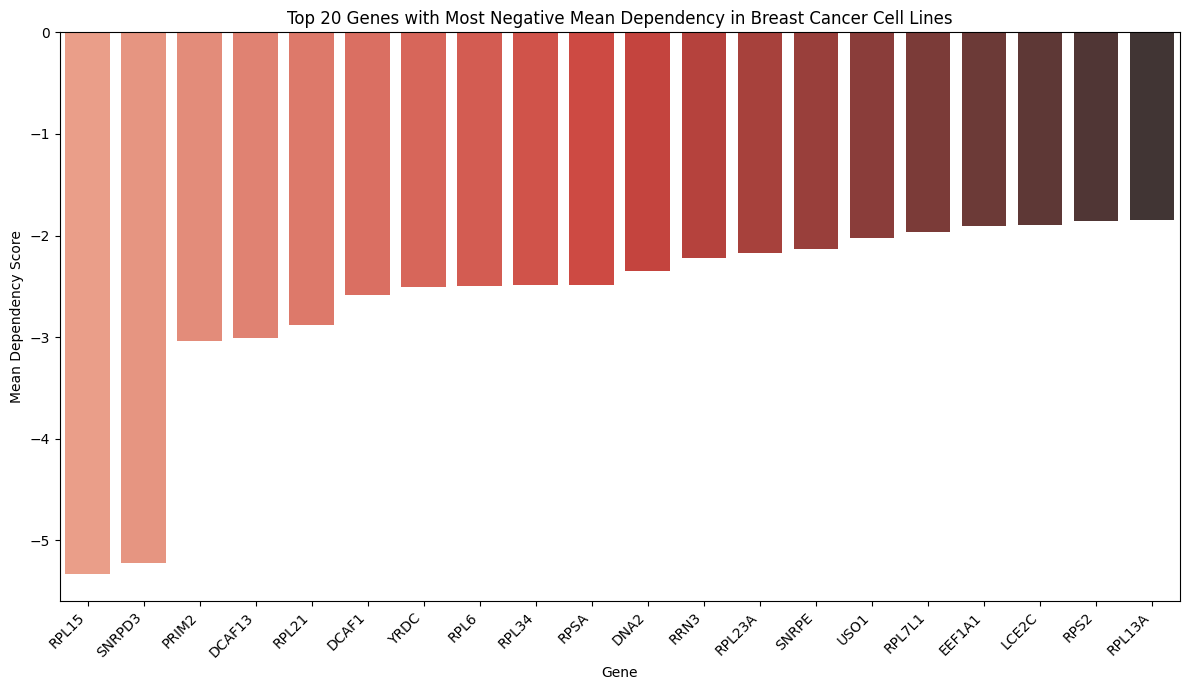

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 20 genes with the most negative mean dependency
bottom_20_genes = df_essential_gene_filtered.head(20)

# Create the bar plot
plt.figure(figsize=(12, 7))

sns.barplot(
    x='Gene',
    y='Mean_Dependency',
    data=bottom_20_genes,
    palette='Reds_d'
)

plt.title('Top 20 Genes with Most Negative Mean Dependency in Breast Cancer Cell Lines')
plt.xlabel('Gene')
plt.ylabel('Mean Dependency Score')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# SAVE FIGURE
plt.savefig(
    "/content/drive/MyDrive/Breast Cancer Model/top20_essential_genes_filtered.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [50]:
df_essential_gene.to_csv(
    "/content/drive/MyDrive/Breast Cancer Model/essentiality_mean_dependency_scores.csv",
    index=False)